# K5 / K8 PCA classifiability diagnostic — QC revision
## Augmented 2025 support · true NCA footprint · random forest only

This notebook revises the PCA experiment after the independent IA45 optical-outlier audit.

The primary question remains:

> Can the 45-dimensional annual-z IA45 representation be compressed into a substantially smaller orthogonal feature space without losing vegetation-state classifiability?

The primary representation is:

\[
Z_{45}
\rightarrow
\mathrm{PCA}_k
\rightarrow
\mathrm{RF},
\]

with

\[
k \in \{2,3,5,10,15,20,30,45\}.
\]

Particular attention is given to **PC10**.

---

## Two parent resolutions

The same observations are evaluated against:

- **K5** coarse vegetation parents;
- **K8** retained finer parent solution.

This keeps the optical sample fixed while changing only ecological label resolution.

---

## True NCA footprint

Only observations inside the true NCA polygon are used. Buffer-only observations are excluded.

---

## Diagnostic 2026 → 2025 augmentation

The augmented support includes 2026 vegetation observations sampled against the 2025 optical surface:

\[
V_{2026}
\leftrightarrow
Z_{2025}.
\]

This is a **deliberate temporal mismatch** used only to approximate the amount of training support available once all current vegetation observations are represented.

It is not a temporally clean estimate of final 2026 performance.

A pseudo-2026 observation can therefore be unusual for its vegetation label simply because the vegetation changed between 2025 and 2026. **Class-conditional mismatch is not an exclusion criterion in this notebook.**

To reduce evaluation leakage:

- only contemporaneous baseline observations are used as held-out test observations;
- pseudo-2026 rows are used as **training augmentation only**;
- pseudo rows sharing a plot key with the held-out fold are excluded from that fold's training data;
- pseudo rows within 100 m of a held-out baseline observation are also excluded from that fold's training data.

Thus the reported grouped OOF scores evaluate contemporaneous observations while asking how classification behaves when pseudo-2026 support is available to the training set.

---

## PCA-specific optical QC exclusion

The independent optical-outlier audit identified one observation as a qualitatively different global optical leverage point:

`20260611_low_69_HAGL` / structural key `low69hagl`.

Audit diagnostics were approximately:

- maximum absolute annual-z: **69.11**
- RMS annual-z: **18.86**
- robust PC10 radius: **72.59**
- mean 10-neighbor distance: **95.58**

The next-most-extreme observations were roughly an order of magnitude smaller on the main global diagnostics.

Therefore `low69hagl` is excluded **only from this temporally mismatched PCA experiment** before any PCA, covariance, or RF fitting occurs.

This is **not** a permanent vegetation-data exclusion. It should not be removed from the vegetation master, K5/K8 clustering, or future contemporaneous 2026 modeling. Once 2026 harmonics are available, the plot should be reconsidered using its correct optical year.

No other observation is removed.

---

## Validation

PCA is always fitted inside each outer training fold:

\[
X_{\mathrm{train}}
\rightarrow
\mathrm{PCA}_{\mathrm{train}},
\]

and the training-fit PCA transformation is applied to the held-out baseline observations.

Random-forest settings are held fixed across representations.

---

## Final raw-vs-z sensitivity

After the annual-z PCA experiment, the notebook compares:

- direct annual-z IA45;
- PC10 from annual-z IA45;
- direct reconstructed raw IA45;
- PC10 from reconstructed raw IA45.

Raw IA45 is reconstructed from the saved annual normalization parameters:

\[
x = z\sigma + \mu.
\]

Raw PCA is centered but not variance-standardized.

In [1]:
# =============================================================================
# 0. IMPORTS / PATHS / SETTINGS
# =============================================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 320)


# -----------------------------------------------------------------------------
# CONTEMPORANEOUS BASELINE
# -----------------------------------------------------------------------------

K5_BASELINE_DATASET = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45_K5"
    r"\FieldVeg_K5_AnnualZScore_IA45_modeling_dataset.csv"
)


# -----------------------------------------------------------------------------
# RESOLVED 2026 VEGETATION -> 2025 OPTICAL SUPPORT
# -----------------------------------------------------------------------------

PSEUDO_2026_DATASET = Path(
    r"C:\NCA_DATA\Analysis\Diagnostics"
    r"\K5_2026Veg_as2025Optics_RESOLVED_v1"
    r"\Tables"
    r"\DIAGNOSTIC_2026veg_sampled_at_2025_IA45_z.csv"
)


# -----------------------------------------------------------------------------
# K8 VEGETATION ASSIGNMENTS
# -----------------------------------------------------------------------------

K8_ASSIGNMENTS = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\Derived"
    r"\NCA_FCM_K8_m1p33_parent_assignments.csv"
)


# -----------------------------------------------------------------------------
# ANNUAL LANDSCAPE Z-SCORE PARAMETERS
# -----------------------------------------------------------------------------

ZSCORE_PARAMETER_CSV = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45"
    r"\annual_IA45_zscore_parameters_S500.csv"
)


# -----------------------------------------------------------------------------
# TRUE NCA FOOTPRINT
# -----------------------------------------------------------------------------

TRUE_NCA_BOUNDARY = Path(
    r"C:\NCA_DATA\templates\SRBOP_NCA_extent_26911.shp"
)


# -----------------------------------------------------------------------------
# OUTPUT
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\Diagnostics"
    r"\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2"
)

TABLE_DIR = OUTPUT_DIR / "Tables"
FIG_DIR = OUTPUT_DIR / "Figures"

ALLOW_OVERWRITE = False


for directory in [
    OUTPUT_DIR,
    TABLE_DIR,
    FIG_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


existing_outputs = [
    p
    for p in OUTPUT_DIR.rglob("*")
    if p.is_file()
]


if existing_outputs and not ALLOW_OVERWRITE:

    raise FileExistsError(
        "PCA diagnostic output directory already contains files.\n"
        "Nothing will be overwritten.\n\n"
        f"{OUTPUT_DIR}"
    )


# -----------------------------------------------------------------------------
# LABELS
# -----------------------------------------------------------------------------

K5_LABELS = {
    1: "PBG",
    2: "ARTR",
    3: "Non-ARTR shrub",
    4: "Exotic forb",
    5: "EAG",
}

K8_LABELS = {
    1: "P1",
    2: "P2",
    3: "P3",
    4: "P4",
    5: "P5",
    6: "P6",
    7: "P7",
    8: "P8",
}


# -----------------------------------------------------------------------------
# RANDOM FOREST
# -----------------------------------------------------------------------------

RANDOM_STATE = 42
N_SPLITS = 5

RF_TEMPLATE = RandomForestClassifier(
    n_estimators=800,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)


# -----------------------------------------------------------------------------
# PCA
# -----------------------------------------------------------------------------

PCA_COMPONENTS = [
    2,
    3,
    5,
    10,
    15,
    20,
    30,
    45,
]

FOCAL_PCA_K = 10


# -----------------------------------------------------------------------------
# AUGMENTATION LEAKAGE GUARD
# -----------------------------------------------------------------------------

PSEUDO_GUARD_M = 100.0


# -----------------------------------------------------------------------------
# PCA-SPECIFIC QC EXCLUSION
#
# IMPORTANT:
# This exclusion applies only to this temporally mismatched PCA diagnostic.
# It is not a permanent vegetation-data exclusion.
# -----------------------------------------------------------------------------

PCA_QC_EXCLUSIONS = [
    {
        "_plot_key": "low69hagl",
        "veg_year_original": 2026,
        "source": "pseudo_2026_as_2025",
        "reason": (
            "Independent IA45 audit identified a gross global optical leverage "
            "point: max_abs_z=69.1089, rms_z=18.8598, robust_PC10_radius=72.5924, "
            "knn10_mean_distance=95.5832. Excluded only from this PCA diagnostic."
        ),
    }
]


print("K5 / K8 PCA CLASSIFIABILITY DIAGNOSTIC — QC REVISION")
print("Output:", OUTPUT_DIR)
print("Pseudo-training guard:", PSEUDO_GUARD_M, "m")

K5 / K8 PCA CLASSIFIABILITY DIAGNOSTIC — QC REVISION
Output: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2
Pseudo-training guard: 100.0 m


In [2]:
# =============================================================================
# 1. HELPERS
# =============================================================================

def clean_plot_id(value):

    if pd.isna(value):
        return None

    s = str(value).strip()

    if (
        s == ""
        or s.lower() == "nan"
    ):
        return None

    if re.fullmatch(
        r"-?\d+\.0",
        s,
    ):
        s = s[:-2]

    return s


def structural_plot_key(value):

    s = clean_plot_id(
        value
    )

    if s is None:
        return None

    s = s.lower()

    # Remove a leading collection-date token.
    s = re.sub(
        r"^(?:\d{8}|\d{6})[_\-\s]+",
        "",
        s,
    )

    # Remove formatting punctuation / whitespace.
    s = re.sub(
        r"[^a-z0-9]+",
        "",
        s,
    )

    return (
        s
        if s
        else None
    )


def write_csv_safe(
    df,
    path,
):

    path = Path(
        path
    )

    if (
        path.exists()
        and not ALLOW_OVERWRITE
    ):
        raise FileExistsError(
            path
        )

    df.to_csv(
        path,
        index=False,
    )

    print(
        "Wrote:",
        path,
    )


def pooled_metrics(
    y_true,
    y_pred,
    label_codes,
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_precision": precision_score(
            y_true,
            y_pred,
            labels=label_codes,
            average="macro",
            zero_division=0,
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            labels=label_codes,
            average="macro",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=label_codes,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=label_codes,
            average="weighted",
            zero_division=0,
        ),
    }


def make_baseline_splits(
    X_baseline,
    y_baseline,
    groups_baseline,
):

    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    return list(
        cv.split(
            X_baseline,
            y_baseline,
            groups=groups_baseline,
        )
    )


def make_augmented_fold_specs(
    y_all,
    label_col_name,
    baseline_idx,
    pseudo_idx,
    groups_baseline,
    xy_all,
    plot_keys_all,
):

    """
    Build fold definitions in which:

      - only contemporaneous baseline observations are held out;
      - pseudo-2026 observations are training augmentation only;
      - pseudo observations sharing a held-out plot key are excluded;
      - pseudo observations within PSEUDO_GUARD_M of a held-out baseline
        observation are excluded.

    Fold stratification uses the requested K5/K8 baseline labels.
    """

    y_baseline = y_all[
        baseline_idx
    ]

    dummy_X = np.zeros(
        (
            len(
                baseline_idx
            ),
            1,
        ),
        dtype=np.float32,
    )


    splits_rel = make_baseline_splits(
        dummy_X,
        y_baseline,
        groups_baseline,
    )


    fold_specs = []


    for fold, (
        train_rel,
        test_rel,
    ) in enumerate(
        splits_rel,
        start=1,
    ):

        train_base_global = baseline_idx[
            train_rel
        ]

        test_base_global = baseline_idx[
            test_rel
        ]


        held_out_keys = set(
            plot_keys_all[
                test_base_global
            ]
        )


        pseudo_keep = np.ones(
            len(
                pseudo_idx
            ),
            dtype=bool,
        )


        # Structural plot-key guard.
        pseudo_keep &= ~np.isin(
            plot_keys_all[
                pseudo_idx
            ],
            list(
                held_out_keys
            ),
        )


        # Spatial guard around held-out contemporaneous observations.
        test_xy = xy_all[
            test_base_global
        ]

        pseudo_xy = xy_all[
            pseudo_idx
        ]


        finite_test = np.isfinite(
            test_xy
        ).all(
            axis=1
        )

        finite_pseudo = np.isfinite(
            pseudo_xy
        ).all(
            axis=1
        )


        if finite_test.any():

            nn = NearestNeighbors(
                n_neighbors=1,
                metric="euclidean",
            )

            nn.fit(
                test_xy[
                    finite_test
                ]
            )


            d = np.full(
                len(
                    pseudo_idx
                ),
                np.inf,
                dtype=float,
            )


            if finite_pseudo.any():

                d[
                    finite_pseudo
                ] = nn.kneighbors(
                    pseudo_xy[
                        finite_pseudo
                    ]
                )[
                    0
                ][
                    :,
                    0
                ]


            pseudo_keep &= (
                d
                > PSEUDO_GUARD_M
            )


        kept_pseudo_global = pseudo_idx[
            pseudo_keep
        ]


        train_aug_global = np.concatenate(
            [
                train_base_global,
                kept_pseudo_global,
            ]
        )


        fold_specs.append(
            {
                "fold": fold,
                "train_base_global": train_base_global,
                "test_base_global": test_base_global,
                "kept_pseudo_global": kept_pseudo_global,
                "train_aug_global": train_aug_global,
                "n_train_baseline": len(
                    train_base_global
                ),
                "n_test_baseline": len(
                    test_base_global
                ),
                "n_pseudo_available": len(
                    pseudo_idx
                ),
                "n_pseudo_kept": len(
                    kept_pseudo_global
                ),
                "n_pseudo_guarded": (
                    len(
                        pseudo_idx
                    )
                    - len(
                        kept_pseudo_global
                    )
                ),
                "label_task": label_col_name,
            }
        )


    return fold_specs


def evaluate_direct_augmented_rf(
    X_all,
    y_all,
    baseline_idx,
    fold_specs,
    label_codes,
):

    """
    Train on baseline-training + guarded pseudo rows.
    Evaluate only on contemporaneous held-out baseline rows.
    """

    y_baseline = y_all[
        baseline_idx
    ]

    baseline_position = {
        global_idx: rel_idx
        for rel_idx, global_idx in enumerate(
            baseline_idx
        )
    }


    oof = np.full(
        len(
            baseline_idx
        ),
        -1,
        dtype=np.int16,
    )


    fold_rows = []


    for spec in fold_specs:

        train_idx = spec[
            "train_aug_global"
        ]

        test_global = spec[
            "test_base_global"
        ]


        model = clone(
            RF_TEMPLATE
        )

        model.fit(
            X_all[
                train_idx
            ],
            y_all[
                train_idx
            ],
        )


        pred = model.predict(
            X_all[
                test_global
            ]
        ).astype(
            np.int16
        )


        test_rel = np.array(
            [
                baseline_position[
                    int(
                        idx
                    )
                ]
                for idx in test_global
            ],
            dtype=int,
        )


        oof[
            test_rel
        ] = pred


        fold_rows.append(
            {
                "fold": spec[
                    "fold"
                ],
                "representation": "direct",
                "n_train_baseline": spec[
                    "n_train_baseline"
                ],
                "n_test_baseline": spec[
                    "n_test_baseline"
                ],
                "n_pseudo_available": spec[
                    "n_pseudo_available"
                ],
                "n_pseudo_kept": spec[
                    "n_pseudo_kept"
                ],
                "n_pseudo_guarded": spec[
                    "n_pseudo_guarded"
                ],
                **pooled_metrics(
                    y_all[
                        test_global
                    ],
                    pred,
                    label_codes,
                ),
            }
        )


    if np.any(
        oof < 0
    ):

        raise RuntimeError(
            "Incomplete contemporaneous-baseline OOF predictions."
        )


    return (
        oof,
        pooled_metrics(
            y_baseline,
            oof,
            label_codes,
        ),
        pd.DataFrame(
            fold_rows
        ),
    )


def evaluate_pca_augmented_rf(
    X_all,
    y_all,
    baseline_idx,
    fold_specs,
    label_codes,
    n_components,
):

    """
    PCA is fitted separately inside every augmented training fold.
    Metrics are calculated only on contemporaneous held-out baseline rows.
    """

    y_baseline = y_all[
        baseline_idx
    ]

    baseline_position = {
        global_idx: rel_idx
        for rel_idx, global_idx in enumerate(
            baseline_idx
        )
    }


    oof = np.full(
        len(
            baseline_idx
        ),
        -1,
        dtype=np.int16,
    )


    fold_rows = []


    for spec in fold_specs:

        train_idx = spec[
            "train_aug_global"
        ]

        test_global = spec[
            "test_base_global"
        ]


        if n_components > min(
            len(
                train_idx
            ),
            X_all.shape[
                1
            ],
        ):

            raise ValueError(
                f"PCA-{n_components} exceeds fold dimensional limit."
            )


        pca = PCA(
            n_components=n_components,
            svd_solver="full",
        )


        X_train_pc = pca.fit_transform(
            X_all[
                train_idx
            ]
        )

        X_test_pc = pca.transform(
            X_all[
                test_global
            ]
        )


        model = clone(
            RF_TEMPLATE
        )

        model.fit(
            X_train_pc,
            y_all[
                train_idx
            ],
        )


        pred = model.predict(
            X_test_pc
        ).astype(
            np.int16
        )


        test_rel = np.array(
            [
                baseline_position[
                    int(
                        idx
                    )
                ]
                for idx in test_global
            ],
            dtype=int,
        )


        oof[
            test_rel
        ] = pred


        fold_rows.append(
            {
                "fold": spec[
                    "fold"
                ],
                "representation": f"PCA{n_components}",
                "n_components": n_components,
                "explained_variance_fraction": float(
                    pca.explained_variance_ratio_.sum()
                ),
                "n_train_baseline": spec[
                    "n_train_baseline"
                ],
                "n_test_baseline": spec[
                    "n_test_baseline"
                ],
                "n_pseudo_available": spec[
                    "n_pseudo_available"
                ],
                "n_pseudo_kept": spec[
                    "n_pseudo_kept"
                ],
                "n_pseudo_guarded": spec[
                    "n_pseudo_guarded"
                ],
                **pooled_metrics(
                    y_all[
                        test_global
                    ],
                    pred,
                    label_codes,
                ),
            }
        )


    if np.any(
        oof < 0
    ):

        raise RuntimeError(
            f"Incomplete PCA-{n_components} contemporaneous-baseline OOF predictions."
        )


    return (
        oof,
        pooled_metrics(
            y_baseline,
            oof,
            label_codes,
        ),
        pd.DataFrame(
            fold_rows
        ),
    )

## 2. Assemble baseline + pseudo-2026 optical support

The complete augmented table is assembled first.

No PCA or RF arrays are created until after:

1. K8 assignment,
2. true-NCA filtering,
3. the single PCA-specific QC exclusion.

This ordering prevents the excluded leverage point from remaining silently inside `X_z` or `X_raw`.

In [3]:
# =============================================================================
# 2. LOAD / COMBINE BASELINE + PSEUDO-2026 SUPPORT
# =============================================================================

for path in [
    K5_BASELINE_DATASET,
    PSEUDO_2026_DATASET,
    K8_ASSIGNMENTS,
    ZSCORE_PARAMETER_CSV,
    TRUE_NCA_BOUNDARY,
]:

    if not path.exists():
        raise FileNotFoundError(
            path
        )


baseline = pd.read_csv(
    K5_BASELINE_DATASET,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)


pseudo = pd.read_csv(
    PSEUDO_2026_DATASET,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)


# -----------------------------------------------------------------------------
# BASELINE KEYS / YEARS
# -----------------------------------------------------------------------------

baseline[
    "PlotID_model"
] = baseline[
    "PlotID"
].map(
    clean_plot_id
)

baseline[
    "_plot_key"
] = baseline[
    "PlotID_model"
].map(
    structural_plot_key
)

baseline[
    "veg_year_original"
] = pd.to_numeric(
    baseline[
        "Year"
    ],
    errors="raise",
).astype(int)

baseline[
    "optical_year"
] = baseline[
    "veg_year_original"
]

baseline[
    "source"
] = "baseline_contemporaneous"


# -----------------------------------------------------------------------------
# PSEUDO-2026 KEYS / YEARS
# -----------------------------------------------------------------------------

pseudo_id_candidates = [
    c
    for c in [
        "Plot",
        "PlotID",
        "coordinate_master_PlotID",
    ]
    if c in pseudo.columns
]


if not pseudo_id_candidates:

    raise KeyError(
        "Pseudo-2026 table has no usable plot identifier."
    )


PSEUDO_ID_COL = pseudo_id_candidates[
    0
]


pseudo[
    "PlotID_model"
] = pseudo[
    PSEUDO_ID_COL
].map(
    clean_plot_id
)

pseudo[
    "_plot_key"
] = pseudo[
    "PlotID_model"
].map(
    structural_plot_key
)


if "veg_year" in pseudo.columns:

    pseudo[
        "veg_year_original"
    ] = pd.to_numeric(
        pseudo[
            "veg_year"
        ],
        errors="raise",
    ).astype(int)

else:

    pseudo[
        "veg_year_original"
    ] = pd.to_numeric(
        pseudo[
            "Year"
        ],
        errors="raise",
    ).astype(int)


pseudo[
    "optical_year"
] = 2025

pseudo[
    "source"
] = "pseudo_2026_as_2025"


# -----------------------------------------------------------------------------
# IA45 SCHEMA
# -----------------------------------------------------------------------------

Z_COLS = [
    c
    for c in baseline.columns
    if str(
        c
    ).startswith(
        "z__"
    )
]


if len(
    Z_COLS
) != 45:

    raise ValueError(
        f"Expected 45 annual-z predictors in baseline; found {len(Z_COLS)}."
    )


missing_pseudo_z = [
    c
    for c in Z_COLS
    if c not in pseudo.columns
]


if missing_pseudo_z:

    raise KeyError(
        f"Pseudo-2026 support missing {len(missing_pseudo_z)} z predictors."
    )


required_common = [
    "PlotID_model",
    "_plot_key",
    "veg_year_original",
    "optical_year",
    "source",
    "Easting",
    "Northing",
    "parent_cluster_k5",
] + Z_COLS


combined = pd.concat(
    [
        baseline[
            required_common
        ].copy(),
        pseudo[
            required_common
        ].copy(),
    ],
    ignore_index=True,
)


for col in [
    "Easting",
    "Northing",
]:

    combined[
        col
    ] = pd.to_numeric(
        combined[
            col
        ],
        errors="coerce",
    )


combined[
    "parent_cluster_k5"
] = pd.to_numeric(
    combined[
        "parent_cluster_k5"
    ],
    errors="coerce",
).astype(
    "Int64"
)


print(
    "Rows before K8 join / NCA filter:",
    len(
        combined
    )
)


display(
    combined[
        "source"
    ].value_counts().rename(
        "n"
    ).to_frame()
)

Rows before K8 join / NCA filter: 921


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_12604\32791184.py:108: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pseudo[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_12604\32791184.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pseudo[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_12604\32791184.py:127: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis

,n
source,
baseline_contemporaneous,479
pseudo_2026_as_2025,442


In [4]:
# =============================================================================
# 3. K8 ASSIGNMENT JOIN
#
# Duplicate Plot-Year source rows are acceptable if they carry the same K8 label.
# Conflicting K8 labels hard-stop.
# =============================================================================

k8 = pd.read_csv(
    K8_ASSIGNMENTS,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)


if "Plot" in k8.columns:

    K8_PLOT_COL = "Plot"

elif "PlotID" in k8.columns:

    K8_PLOT_COL = "PlotID"

else:

    raise KeyError(
        "K8 assignment table contains neither Plot nor PlotID."
    )


if "parent_cluster" in k8.columns:

    K8_LABEL_COL = "parent_cluster"

elif "parent_cluster_k8" in k8.columns:

    K8_LABEL_COL = "parent_cluster_k8"

else:

    raise KeyError(
        "Could not identify K8 parent-cluster column."
    )


k8[
    "Year"
] = pd.to_numeric(
    k8[
        "Year"
    ],
    errors="coerce",
)

k8[
    "_plot_key"
] = k8[
    K8_PLOT_COL
].map(
    structural_plot_key
)


k8_small = (
    k8[
        [
            "_plot_key",
            "Year",
            K8_LABEL_COL,
        ]
    ]
    .rename(
        columns={
            "Year": "veg_year_original",
            K8_LABEL_COL: "parent_cluster_k8",
        }
    )
    .copy()
)


k8_small[
    "parent_cluster_k8"
] = pd.to_numeric(
    k8_small[
        "parent_cluster_k8"
    ],
    errors="coerce",
)


label_counts = (
    k8_small.groupby(
        [
            "_plot_key",
            "veg_year_original",
        ]
    )[
        "parent_cluster_k8"
    ]
    .nunique(
        dropna=True
    )
)


conflicting_keys = label_counts[
    label_counts
    > 1
]


print(
    "K8 raw assignment rows:",
    len(
        k8_small
    )
)

print(
    "Conflicting Plot-Year labels:",
    len(
        conflicting_keys
    )
)


if len(
    conflicting_keys
) > 0:

    conflict_index = (
        conflicting_keys
        .reset_index()[
            [
                "_plot_key",
                "veg_year_original",
            ]
        ]
    )


    conflict_rows = k8_small.merge(
        conflict_index,
        on=[
            "_plot_key",
            "veg_year_original",
        ],
        how="inner",
    ).sort_values(
        [
            "_plot_key",
            "veg_year_original",
            "parent_cluster_k8",
        ]
    )


    display(
        conflict_rows
    )


    raise ValueError(
        "Some Plot-Year keys have conflicting K8 parent assignments."
    )


k8_lookup = (
    k8_small
    .dropna(
        subset=[
            "_plot_key",
            "veg_year_original",
            "parent_cluster_k8",
        ]
    )
    .drop_duplicates(
        subset=[
            "_plot_key",
            "veg_year_original",
        ],
        keep="first",
    )
    .reset_index(
        drop=True
    )
)


k8_lookup[
    "parent_cluster_k8"
] = k8_lookup[
    "parent_cluster_k8"
].astype(int)


combined = combined.merge(
    k8_lookup,
    on=[
        "_plot_key",
        "veg_year_original",
    ],
    how="left",
    validate="many_to_one",
)


missing_k8 = combined[
    "parent_cluster_k8"
].isna()


print(
    "\nRows missing K8 label:",
    int(
        missing_k8.sum()
    ),
    "/",
    len(
        combined
    ),
)


if missing_k8.any():

    display(
        combined.loc[
            missing_k8,
            [
                "PlotID_model",
                "_plot_key",
                "veg_year_original",
                "source",
            ],
        ].head(
            50
        )
    )


if missing_k8.mean() > 0.02:

    raise ValueError(
        "More than 2% of the augmented dataset failed the K8 assignment join."
    )


combined = (
    combined.loc[
        ~missing_k8
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


combined[
    "parent_cluster_k8"
] = pd.to_numeric(
    combined[
        "parent_cluster_k8"
    ],
    errors="raise",
).astype(int)


print(
    "\nRows retained after K8 join:",
    len(
        combined
    )
)

K8 raw assignment rows: 1171
Conflicting Plot-Year labels: 0

Rows missing K8 label: 1 / 921


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_12604\2611463436.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  k8[


,PlotID_model,_plot_key,veg_year_original,source
382,20250925_bapr1,bapr1,2025,baseline_contemporaneous



Rows retained after K8 join: 920


## 4. Restrict to the true NCA footprint

In [5]:
# =============================================================================
# 4. TRUE NCA FILTER
# =============================================================================

nca = gpd.read_file(
    TRUE_NCA_BOUNDARY
)


if nca.crs is None:

    raise ValueError(
        "True NCA boundary has no CRS metadata."
    )


points = gpd.GeoDataFrame(
    combined.copy(),
    geometry=gpd.points_from_xy(
        combined[
            "Easting"
        ],
        combined[
            "Northing"
        ],
    ),
    crs="EPSG:26911",
)


if points.crs != nca.crs:

    nca_for_points = nca.to_crs(
        points.crs
    )

else:

    nca_for_points = nca


try:

    nca_union = nca_for_points.geometry.union_all()

except AttributeError:

    nca_union = nca_for_points.geometry.unary_union


inside_nca = points.geometry.intersects(
    nca_union
)


print(
    "Rows before true-NCA filter:",
    len(
        combined
    )
)

print(
    "Rows inside true NCA:",
    int(
        inside_nca.sum()
    )
)

print(
    "Rows excluded as buffer/outside:",
    int(
        (
            ~inside_nca
        ).sum()
    )
)


analysis_df = (
    combined.loc[
        inside_nca.to_numpy()
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


analysis_df = analysis_df.loc[
    analysis_df[
        "parent_cluster_k5"
    ].notna()
    & analysis_df[
        "parent_cluster_k8"
    ].notna()
].copy().reset_index(
    drop=True
)


analysis_df[
    "parent_cluster_k5"
] = analysis_df[
    "parent_cluster_k5"
].astype(int)

analysis_df[
    "parent_cluster_k8"
] = analysis_df[
    "parent_cluster_k8"
].astype(int)


print(
    "\nCommon true-NCA observations before PCA QC:",
    len(
        analysis_df
    )
)


display(
    analysis_df[
        "source"
    ].value_counts().rename(
        "n"
    ).to_frame()
)

Rows before true-NCA filter: 920
Rows inside true NCA: 775
Rows excluded as buffer/outside: 145

Common true-NCA observations before PCA QC: 775


,n
source,
pseudo_2026_as_2025,422
baseline_contemporaneous,353


## 5. Apply the independently reviewed PCA-specific optical exclusion

Only the exact audited observation is removed.

No automatic z-score, PCA-distance, class-distance, or kNN threshold is applied here.

This prevents the PCA experiment from recursively deciding which difficult observations to delete.

In [6]:
# =============================================================================
# 5. APPLY PCA-SPECIFIC QC EXCLUSION BEFORE ANY X MATRIX IS BUILT
# =============================================================================

exclusion_records = []


for rule in PCA_QC_EXCLUSIONS:

    mask = (
        analysis_df[
            "_plot_key"
        ].eq(
            rule[
                "_plot_key"
            ]
        )
        & analysis_df[
            "veg_year_original"
        ].eq(
            rule[
                "veg_year_original"
            ]
        )
        & analysis_df[
            "source"
        ].eq(
            rule[
                "source"
            ]
        )
    )


    matched = analysis_df.loc[
        mask
    ].copy()


    if len(
        matched
    ) != 1:

        raise ValueError(
            "Expected exactly one PCA-QC row for rule "
            f"{rule}; found {len(matched)}."
        )


    matched[
        "exclusion_reason"
    ] = rule[
        "reason"
    ]


    exclusion_records.append(
        matched
    )


excluded_df = pd.concat(
    exclusion_records,
    ignore_index=True,
)


display(
    excluded_df[
        [
            "PlotID_model",
            "_plot_key",
            "veg_year_original",
            "optical_year",
            "source",
            "Easting",
            "Northing",
            "parent_cluster_k5",
            "parent_cluster_k8",
            "exclusion_reason",
        ]
    ]
)


write_csv_safe(
    excluded_df,
    TABLE_DIR
    / "DIAGNOSTIC_PCA_specific_QC_exclusions.csv",
)


exclude_index = set(
    excluded_df[
        "_plot_key"
    ].astype(str)
    + "__"
    + excluded_df[
        "veg_year_original"
    ].astype(str)
    + "__"
    + excluded_df[
        "source"
    ].astype(str)
)


row_keys = (
    analysis_df[
        "_plot_key"
    ].astype(str)
    + "__"
    + analysis_df[
        "veg_year_original"
    ].astype(str)
    + "__"
    + analysis_df[
        "source"
    ].astype(str)
)


analysis_df = (
    analysis_df.loc[
        ~row_keys.isin(
            exclude_index
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "\nFinal common true-NCA observations after PCA QC:",
    len(
        analysis_df
    )
)


print(
    "\nSource composition:"
)

display(
    analysis_df[
        "source"
    ].value_counts().rename(
        "n"
    ).to_frame()
)


print(
    "\nK5 counts:"
)

display(
    analysis_df[
        "parent_cluster_k5"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "n"
    )
    .to_frame()
)


print(
    "\nK8 counts:"
)

display(
    analysis_df[
        "parent_cluster_k8"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "n"
    )
    .to_frame()
)

,PlotID_model,_plot_key,veg_year_original,optical_year,source,Easting,Northing,parent_cluster_k5,parent_cluster_k8,exclusion_reason
0,20260611_low_69_HAGL,low69hagl,2026,2025,pseudo_2026_as_2025,554758.345,4.775680e+06,4,3,Independent IA45 audit identified a gross glob...


Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2\Tables\DIAGNOSTIC_PCA_specific_QC_exclusions.csv

Final common true-NCA observations after PCA QC: 774

Source composition:


,n
source,
pseudo_2026_as_2025,421
baseline_contemporaneous,353



K5 counts:


,n
parent_cluster_k5,
1,125
2,92
3,117
4,157
5,283



K8 counts:


,n
parent_cluster_k8,
1,123
2,80
3,89
4,171
5,62
6,77
7,76
8,96


## 6. Build annual-z and reconstructed raw IA45 matrices

This occurs **after** the QC exclusion.

That ordering is essential: the excluded leverage point never enters the PCA basis, RF training matrices, or raw-vs-z comparison.

In [7]:
# =============================================================================
# 6. BUILD X_z + RECONSTRUCT RAW IA45
# =============================================================================

FEATURES = [
    c.replace(
        "z__",
        "",
        1,
    )
    for c in Z_COLS
]


X_z = analysis_df[
    Z_COLS
].to_numpy(
    dtype=np.float64
)


if not np.isfinite(
    X_z
).all():

    raise ValueError(
        "Non-finite values exist in final annual-z IA45 matrix."
    )


# -----------------------------------------------------------------------------
# RECONSTRUCT RAW IA45
# -----------------------------------------------------------------------------

params = pd.read_csv(
    ZSCORE_PARAMETER_CSV
)


params[
    "Year"
] = pd.to_numeric(
    params[
        "Year"
    ],
    errors="raise",
).astype(int)


if "weighted_mean" in params.columns:

    MEAN_COL = "weighted_mean"

elif "mean" in params.columns:

    MEAN_COL = "mean"

else:

    raise KeyError(
        "Could not identify z-score mean column."
    )


if "weighted_sd" in params.columns:

    SD_COL = "weighted_sd"

elif "sd" in params.columns:

    SD_COL = "sd"

elif "std" in params.columns:

    SD_COL = "std"

else:

    raise KeyError(
        "Could not identify z-score SD column."
    )


X_raw = np.full(
    X_z.shape,
    np.nan,
    dtype=np.float64,
)


for year in sorted(
    analysis_df[
        "optical_year"
    ].unique()
):

    mask = (
        analysis_df[
            "optical_year"
        ].to_numpy()
        == year
    )


    p_year = (
        params.loc[
            params[
                "Year"
            ].eq(
                int(
                    year
                )
            )
        ]
        .set_index(
            "feature"
        )
    )


    missing = [
        feature
        for feature in FEATURES
        if feature not in p_year.index
    ]


    if missing:

        raise KeyError(
            f"{year}: missing normalization parameters for {missing}"
        )


    mu = p_year.loc[
        FEATURES,
        MEAN_COL,
    ].to_numpy(
        dtype=np.float64
    )


    sd = p_year.loc[
        FEATURES,
        SD_COL,
    ].to_numpy(
        dtype=np.float64
    )


    X_raw[
        mask
    ] = (
        X_z[
            mask
        ]
        * sd[
            None,
            :
        ]
        + mu[
            None,
            :
        ]
    )


if not np.isfinite(
    X_raw
).all():

    raise ValueError(
        "Non-finite values remain after raw IA45 reconstruction."
    )


RAW_COLS = [
    f"raw__{feature}"
    for feature in FEATURES
]


for j, col in enumerate(
    RAW_COLS
):

    analysis_df[
        col
    ] = X_raw[
        :,
        j
    ]


# -----------------------------------------------------------------------------
# SOURCE INDEX SETS
# -----------------------------------------------------------------------------

baseline_mask = analysis_df[
    "source"
].eq(
    "baseline_contemporaneous"
).to_numpy()


pseudo_mask = analysis_df[
    "source"
].eq(
    "pseudo_2026_as_2025"
).to_numpy()


baseline_idx = np.where(
    baseline_mask
)[
    0
]

pseudo_idx = np.where(
    pseudo_mask
)[
    0
]


xy_all = analysis_df[
    [
        "Easting",
        "Northing",
    ]
].to_numpy(
    dtype=float
)


plot_keys_all = analysis_df[
    "_plot_key"
].astype(str).to_numpy()


print(
    "Final IA45 matrix:",
    X_z.shape
)

print(
    "Contemporaneous baseline evaluation rows:",
    len(
        baseline_idx
    )
)

print(
    "Pseudo-2026 augmentation rows:",
    len(
        pseudo_idx
    )
)


write_csv_safe(
    analysis_df,
    TABLE_DIR
    / "DIAGNOSTIC_common_trueNCA_augmented2025_after_PCA_QC.csv",
)

Final IA45 matrix: (774, 45)
Contemporaneous baseline evaluation rows: 353
Pseudo-2026 augmentation rows: 421
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2\Tables\DIAGNOSTIC_common_trueNCA_augmented2025_after_PCA_QC.csv


In [8]:
# =============================================================================
# 7. POST-QC SANITY CHECK — NO ADDITIONAL EXCLUSIONS
#
# This is descriptive only.
# =============================================================================

abs_z = np.abs(
    X_z
)


sanity_df = analysis_df[
    [
        "PlotID_model",
        "_plot_key",
        "veg_year_original",
        "optical_year",
        "source",
        "parent_cluster_k5",
        "parent_cluster_k8",
    ]
].copy()


sanity_df[
    "max_abs_z"
] = abs_z.max(
    axis=1
)

sanity_df[
    "rms_z"
] = np.sqrt(
    np.mean(
        X_z ** 2,
        axis=1,
    )
)


print(
    "Post-QC maximum |z|:",
    round(
        float(
            sanity_df[
                "max_abs_z"
            ].max()
        ),
        4,
    )
)


display(
    sanity_df.sort_values(
        [
            "max_abs_z",
            "rms_z",
        ],
        ascending=False,
    ).head(
        15
    ).round(
        4
    )
)

Post-QC maximum |z|: 8.2696


,PlotID_model,_plot_key,veg_year_original,optical_year,source,parent_cluster_k5,parent_cluster_k8,max_abs_z,rms_z
165,884,884,2016,2016,baseline_contemporaneous,4,3,8.2696,3.0359
544,high_38_21,high3821,2026,2025,pseudo_2026_as_2025,2,7,7.3119,1.8837
416,B3_12,b312,2026,2025,pseudo_2026_as_2025,5,6,5.3829,1.4246
166,886,886,2016,2016,baseline_contemporaneous,4,8,5.3132,2.6754
292,20251023_artr2,artr2,2025,2025,baseline_contemporaneous,2,7,5.1671,1.0885
417,B3_13,b313,2026,2025,pseudo_2026_as_2025,4,8,4.8344,1.3809
35,189,189,2018,2018,baseline_contemporaneous,5,4,4.7372,1.9465
422,B3_32,b332,2026,2025,pseudo_2026_as_2025,4,3,4.5043,1.3385
215,951,951,2016,2016,baseline_contemporaneous,5,4,4.2878,1.4107
419,B3_22,b322,2026,2025,pseudo_2026_as_2025,4,3,4.2742,1.2884


# Primary analysis — PCA on annual-z IA45

The full-data PCA below is **descriptive only**.

All predictive evaluation later fits PCA independently inside each augmented training fold.

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2\Tables\DIAGNOSTIC_zPCA_explained_variance.csv
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2\Tables\DIAGNOSTIC_zPCA_loadings_descriptive_only.csv


,pc,explained_variance_ratio,cumulative_explained_variance
0,1,0.3108,0.3108
1,2,0.1868,0.4976
2,3,0.1094,0.6070
3,4,0.0691,0.6761
4,5,0.0604,0.7365
5,6,0.0443,0.7808
6,7,0.0369,0.8178
7,8,0.0315,0.8493
8,9,0.0266,0.8758
9,10,0.0237,0.8995


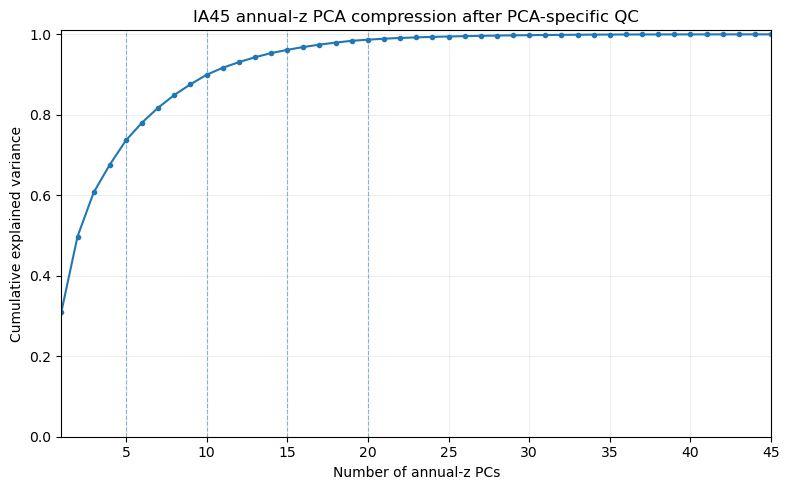

In [9]:
# =============================================================================
# 8. DESCRIPTIVE ANNUAL-Z PCA
# =============================================================================

pca_full_z = PCA(
    n_components=45,
    svd_solver="full",
)


PC_z_full = pca_full_z.fit_transform(
    X_z
)


explained_z = pd.DataFrame(
    {
        "pc": np.arange(
            1,
            46,
        ),
        "explained_variance_ratio": pca_full_z.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(
            pca_full_z.explained_variance_ratio_
        ),
    }
)


write_csv_safe(
    explained_z,
    TABLE_DIR
    / "DIAGNOSTIC_zPCA_explained_variance.csv",
)


loadings_z = pd.DataFrame(
    pca_full_z.components_.T,
    index=FEATURES,
    columns=[
        f"PC{i}"
        for i in range(
            1,
            46,
        )
    ],
).reset_index(
    names="feature"
)


write_csv_safe(
    loadings_z,
    TABLE_DIR
    / "DIAGNOSTIC_zPCA_loadings_descriptive_only.csv",
)


display(
    explained_z.head(
        15
    ).round(
        4
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


ax.plot(
    explained_z[
        "pc"
    ],
    explained_z[
        "cumulative_explained_variance"
    ],
    marker="o",
    markersize=3,
)


for k in [
    5,
    10,
    15,
    20,
]:

    ax.axvline(
        k,
        linewidth=0.8,
        linestyle="--",
        alpha=0.5,
    )


ax.set_xlim(
    1,
    45
)

ax.set_ylim(
    0,
    1.01
)

ax.set_xlabel(
    "Number of annual-z PCs"
)

ax.set_ylabel(
    "Cumulative explained variance"
)

ax.set_title(
    "IA45 annual-z PCA compression after PCA-specific QC"
)

ax.grid(
    alpha=0.2
)


plt.tight_layout()


fig_path = (
    FIG_DIR
    / "zPCA_cumulative_explained_variance.png"
)


fig.savefig(
    fig_path,
    dpi=250,
    bbox_inches="tight",
)


plt.show()
plt.close(
    fig
)

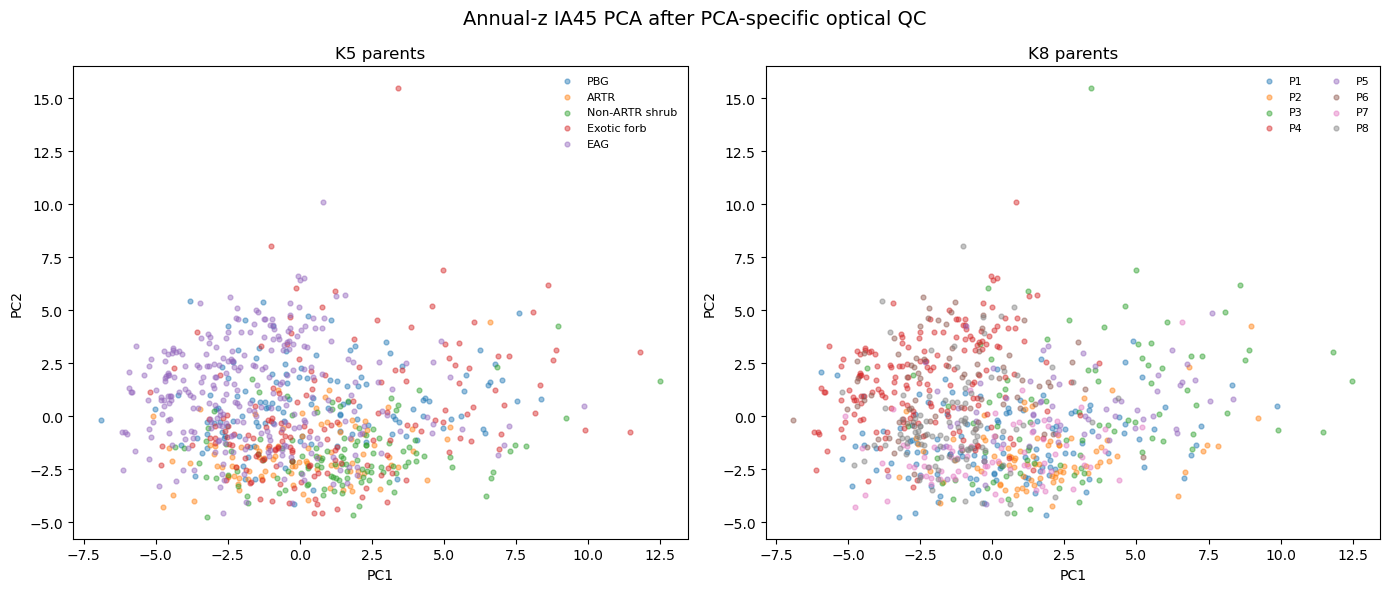

In [10]:
# =============================================================================
# 9. PC1 / PC2 GEOMETRY — K5 AND K8
# =============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        14,
        6,
    )
)


for code_i in sorted(
    K5_LABELS
):

    mask = (
        analysis_df[
            "parent_cluster_k5"
        ].to_numpy()
        == code_i
    )


    axes[
        0
    ].scatter(
        PC_z_full[
            mask,
            0
        ],
        PC_z_full[
            mask,
            1
        ],
        s=12,
        alpha=0.45,
        label=K5_LABELS[
            code_i
        ],
    )


axes[
    0
].set_title(
    "K5 parents"
)

axes[
    0
].set_xlabel(
    "PC1"
)

axes[
    0
].set_ylabel(
    "PC2"
)

axes[
    0
].legend(
    frameon=False,
    fontsize=8,
)


for code_i in sorted(
    K8_LABELS
):

    mask = (
        analysis_df[
            "parent_cluster_k8"
        ].to_numpy()
        == code_i
    )


    axes[
        1
    ].scatter(
        PC_z_full[
            mask,
            0
        ],
        PC_z_full[
            mask,
            1
        ],
        s=12,
        alpha=0.45,
        label=K8_LABELS[
            code_i
        ],
    )


axes[
    1
].set_title(
    "K8 parents"
)

axes[
    1
].set_xlabel(
    "PC1"
)

axes[
    1
].set_ylabel(
    "PC2"
)

axes[
    1
].legend(
    frameon=False,
    fontsize=8,
    ncol=2,
)


fig.suptitle(
    "Annual-z IA45 PCA after PCA-specific optical QC",
    fontsize=14,
)


plt.tight_layout()


fig_path = (
    FIG_DIR
    / "zPCA_PC1_PC2_K5_K8_after_QC.png"
)


fig.savefig(
    fig_path,
    dpi=250,
    bbox_inches="tight",
)


plt.show()
plt.close(
    fig
)

## 10. Contemporaneous held-out RF evaluation with pseudo-2026 training augmentation

This is the main predictive experiment.

For every K5/K8 fold:

1. Split only the **contemporaneous baseline** observations.
2. Hold the test fold completely out.
3. Add pseudo-2026 rows to the training set only.
4. Remove pseudo rows with the same plot key as a held-out observation.
5. Remove pseudo rows within 100 m of any held-out baseline observation.
6. Fit direct RF or training-fold PCA → RF.
7. Score only the held-out contemporaneous baseline rows.

This means the metrics are not performance estimates on the temporally mismatched pseudo-2026 observations.

In [11]:
# =============================================================================
# 10. DEFINE K5 / K8 FOLDS WITH AUGMENTATION GUARDS
# =============================================================================

TASKS = {
    "K5": {
        "label_col": "parent_cluster_k5",
        "label_codes": sorted(
            K5_LABELS
        ),
    },
    "K8": {
        "label_col": "parent_cluster_k8",
        "label_codes": sorted(
            K8_LABELS
        ),
    },
}


TASK_FOLD_SPECS = {}


fold_audit_rows = []


for task_name, task in TASKS.items():

    y_all = analysis_df[
        task[
            "label_col"
        ]
    ].to_numpy(
        dtype=int
    )


    groups_baseline = plot_keys_all[
        baseline_idx
    ]


    specs = make_augmented_fold_specs(
        y_all=y_all,
        label_col_name=task_name,
        baseline_idx=baseline_idx,
        pseudo_idx=pseudo_idx,
        groups_baseline=groups_baseline,
        xy_all=xy_all,
        plot_keys_all=plot_keys_all,
    )


    TASK_FOLD_SPECS[
        task_name
    ] = specs


    for spec in specs:

        fold_audit_rows.append(
            {
                "task": task_name,
                "fold": spec[
                    "fold"
                ],
                "n_train_baseline": spec[
                    "n_train_baseline"
                ],
                "n_test_baseline": spec[
                    "n_test_baseline"
                ],
                "n_pseudo_available": spec[
                    "n_pseudo_available"
                ],
                "n_pseudo_kept": spec[
                    "n_pseudo_kept"
                ],
                "n_pseudo_guarded": spec[
                    "n_pseudo_guarded"
                ],
            }
        )


fold_audit_df = pd.DataFrame(
    fold_audit_rows
)


write_csv_safe(
    fold_audit_df,
    TABLE_DIR
    / "DIAGNOSTIC_augmented_fold_composition.csv",
)


display(
    fold_audit_df
)

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2\Tables\DIAGNOSTIC_augmented_fold_composition.csv


,task,fold,n_train_baseline,n_test_baseline,n_pseudo_available,n_pseudo_kept,n_pseudo_guarded
0,K5,1,283,70,421,421,0
1,K5,2,285,68,421,420,1
2,K5,3,278,75,421,421,0
3,K5,4,286,67,421,421,0
4,K5,5,280,73,421,420,1
5,K8,1,285,68,421,420,1
6,K8,2,283,70,421,420,1
7,K8,3,281,72,421,421,0
8,K8,4,281,72,421,421,0
9,K8,5,282,71,421,421,0


In [12]:
# =============================================================================
# 11. ANNUAL-Z PCA CLASSIFICATION SWEEP
# =============================================================================

z_results = []
z_fold_results = []
z_oof_predictions = {}


for task_name, task in TASKS.items():

    print(
        "\n"
        + "=" * 96
    )

    print(
        task_name,
        "ANNUAL-Z PCA SWEEP"
    )

    print(
        "=" * 96
    )


    y_all = analysis_df[
        task[
            "label_col"
        ]
    ].to_numpy(
        dtype=int
    )


    specs = TASK_FOLD_SPECS[
        task_name
    ]


    # -------------------------------------------------------------------------
    # DIRECT Z45
    # -------------------------------------------------------------------------

    pred_direct, metrics_direct, direct_fold_df = evaluate_direct_augmented_rf(
        X_all=X_z,
        y_all=y_all,
        baseline_idx=baseline_idx,
        fold_specs=specs,
        label_codes=task[
            "label_codes"
        ],
    )


    z_oof_predictions[
        (
            task_name,
            "Z45_direct",
        )
    ] = pred_direct


    z_results.append(
        {
            "task": task_name,
            "representation": "Z45_direct",
            "n_components": 45,
            "is_pca": False,
            "mean_fold_explained_variance": 1.0,
            **metrics_direct,
        }
    )


    direct_fold_df[
        "task"
    ] = task_name

    direct_fold_df[
        "representation"
    ] = "Z45_direct"

    z_fold_results.append(
        direct_fold_df
    )


    # -------------------------------------------------------------------------
    # PCA SWEEP
    # -------------------------------------------------------------------------

    for k in PCA_COMPONENTS:

        pred, metrics, fold_df = evaluate_pca_augmented_rf(
            X_all=X_z,
            y_all=y_all,
            baseline_idx=baseline_idx,
            fold_specs=specs,
            label_codes=task[
                "label_codes"
            ],
            n_components=k,
        )


        representation = f"zPCA{k}"


        z_oof_predictions[
            (
                task_name,
                representation,
            )
        ] = pred


        z_results.append(
            {
                "task": task_name,
                "representation": representation,
                "n_components": k,
                "is_pca": True,
                "mean_fold_explained_variance": float(
                    fold_df[
                        "explained_variance_fraction"
                    ].mean()
                ),
                **metrics,
            }
        )


        fold_df[
            "task"
        ] = task_name

        fold_df[
            "representation"
        ] = representation

        z_fold_results.append(
            fold_df
        )


z_results_df = pd.DataFrame(
    z_results
)


z_fold_results_df = pd.concat(
    z_fold_results,
    ignore_index=True,
)


write_csv_safe(
    z_results_df,
    TABLE_DIR
    / "DIAGNOSTIC_zPCA_contemporaneous_OOF_performance.csv",
)


write_csv_safe(
    z_fold_results_df,
    TABLE_DIR
    / "DIAGNOSTIC_zPCA_contemporaneous_OOF_fold_performance.csv",
)


display(
    z_results_df.sort_values(
        [
            "task",
            "n_components",
            "is_pca",
        ]
    ).round(
        4
    )
)


K5 ANNUAL-Z PCA SWEEP

K8 ANNUAL-Z PCA SWEEP
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2\Tables\DIAGNOSTIC_zPCA_contemporaneous_OOF_performance.csv
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2\Tables\DIAGNOSTIC_zPCA_contemporaneous_OOF_fold_performance.csv


,task,representation,n_components,is_pca,mean_fold_explained_variance,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
1,K5,zPCA2,2,True,0.4973,0.4533,0.4311,0.4267,0.4311,0.4240,0.4548
2,K5,zPCA3,3,True,0.6081,0.4844,0.4461,0.4448,0.4461,0.4397,0.4761
3,K5,zPCA5,5,True,0.7367,0.5184,0.4957,0.4949,0.4957,0.4911,0.5107
4,K5,zPCA10,10,True,0.9009,0.5694,0.5464,0.5716,0.5464,0.5511,0.5654
5,K5,zPCA15,15,True,0.9621,0.5751,0.5460,0.5788,0.5460,0.5505,0.5675
6,K5,zPCA20,20,True,0.9871,0.5779,0.5380,0.5870,0.5380,0.5477,0.5711
7,K5,zPCA30,30,True,0.9981,0.5722,0.5179,0.5756,0.5179,0.5252,0.5595
0,K5,Z45_direct,45,False,1.0000,0.5864,0.5702,0.5777,0.5702,0.5657,0.5763
8,K5,zPCA45,45,True,1.0000,0.5581,0.5018,0.5788,0.5018,0.5085,0.5420
10,K8,zPCA2,2,True,0.4975,0.3371,0.3245,0.3164,0.3245,0.3137,0.3374


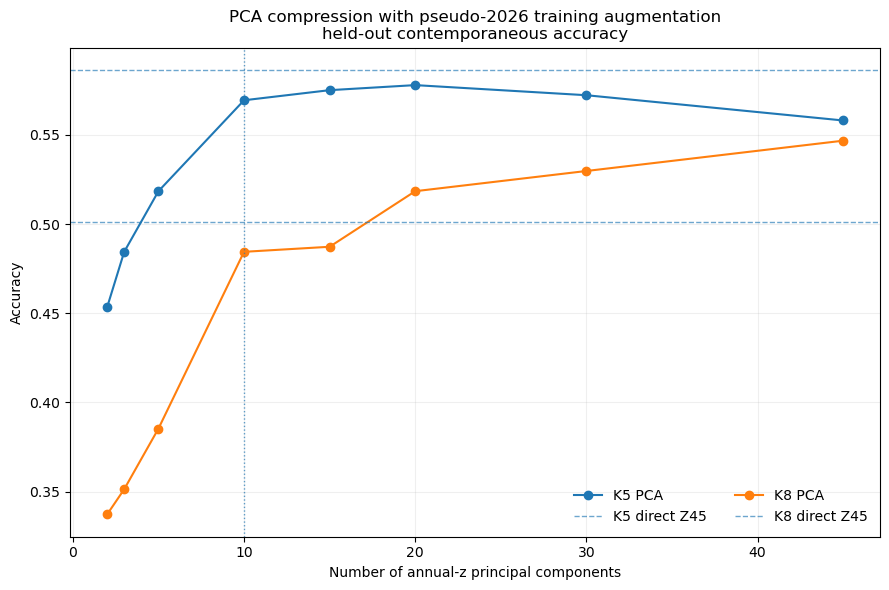

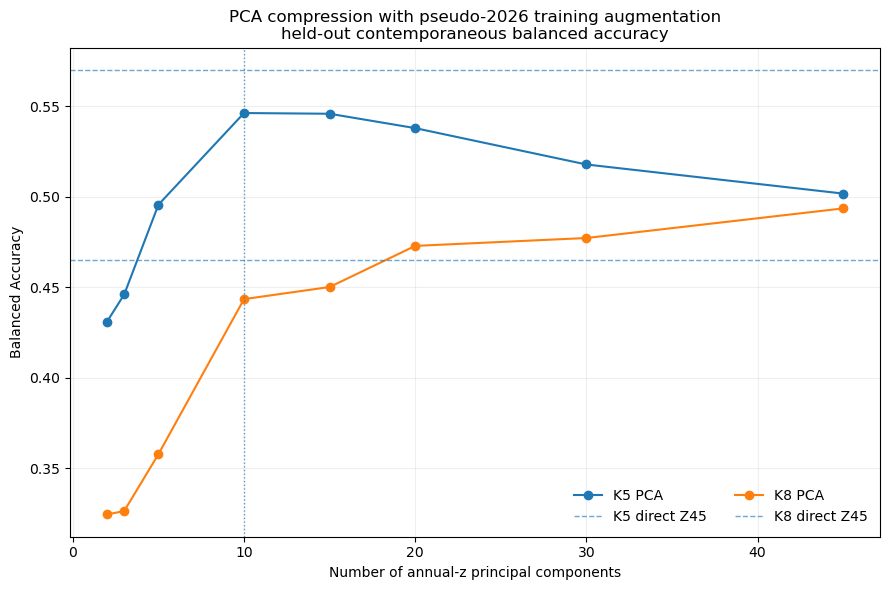

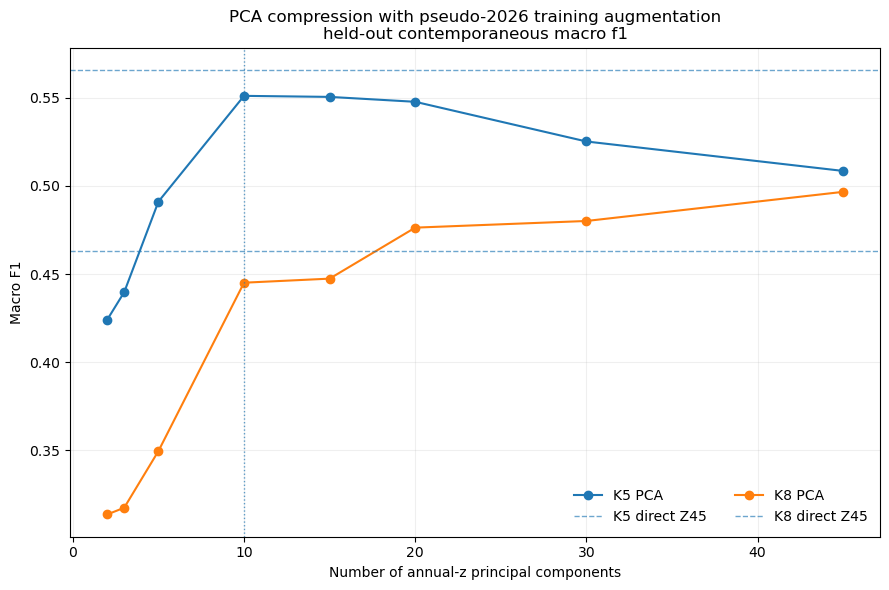

In [13]:
# =============================================================================
# 12. PERFORMANCE CURVES
# =============================================================================

for metric in [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
]:

    fig, ax = plt.subplots(
        figsize=(
            9,
            6,
        )
    )


    for task_name in [
        "K5",
        "K8",
    ]:

        part = (
            z_results_df.loc[
                z_results_df[
                    "task"
                ].eq(
                    task_name
                )
                & z_results_df[
                    "is_pca"
                ].eq(
                    True
                )
            ]
            .sort_values(
                "n_components"
            )
        )


        ax.plot(
            part[
                "n_components"
            ],
            part[
                metric
            ],
            marker="o",
            label=f"{task_name} PCA",
        )


        direct_value = (
            z_results_df.loc[
                z_results_df[
                    "task"
                ].eq(
                    task_name
                )
                & z_results_df[
                    "representation"
                ].eq(
                    "Z45_direct"
                ),
                metric,
            ]
            .iloc[
                0
            ]
        )


        ax.axhline(
            direct_value,
            linestyle="--",
            linewidth=1,
            alpha=0.65,
            label=f"{task_name} direct Z45",
        )


    ax.axvline(
        FOCAL_PCA_K,
        linestyle=":",
        linewidth=1,
        alpha=0.7,
    )


    ax.set_xlabel(
        "Number of annual-z principal components"
    )

    ax.set_ylabel(
        metric.replace(
            "_",
            " "
        ).title()
    )

    ax.set_title(
        "PCA compression with pseudo-2026 training augmentation\n"
        f"held-out contemporaneous {metric.replace('_', ' ')}"
    )

    ax.legend(
        frameon=False,
        ncol=2,
    )

    ax.grid(
        alpha=0.2
    )


    plt.tight_layout()


    fig_path = (
        FIG_DIR
        / f"zPCA_{metric}_curve_K5_K8.png"
    )


    fig.savefig(
        fig_path,
        dpi=250,
        bbox_inches="tight",
    )


    plt.show()
    plt.close(
        fig
    )

## 13. Focal comparison: direct Z45, zPCA10, zPCA45

`zPCA45` retains all dimensions but rotates the feature space, so:

\[
Z_{45}
\rightarrow
PC_{45}
\]

primarily tests RF sensitivity to rotation.

The comparison

\[
PC_{45}
\rightarrow
PC_{10}
\]

adds dimensional compression.

In [14]:
# =============================================================================
# 13. FOCAL COMPARISON
# =============================================================================

focal_z = z_results_df.loc[
    z_results_df[
        "representation"
    ].isin(
        [
            "Z45_direct",
            "zPCA10",
            "zPCA45",
        ]
    )
].copy()


display(
    focal_z[
        [
            "task",
            "representation",
            "mean_fold_explained_variance",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
        ]
    ]
    .sort_values(
        [
            "task",
            "representation",
        ]
    )
    .round(
        4
    )
)


delta_rows = []


for task_name in [
    "K5",
    "K8",
]:

    base = (
        focal_z.loc[
            focal_z[
                "task"
            ].eq(
                task_name
            )
            & focal_z[
                "representation"
            ].eq(
                "Z45_direct"
            )
        ]
        .iloc[
            0
        ]
    )


    for representation in [
        "zPCA10",
        "zPCA45",
    ]:

        row = (
            focal_z.loc[
                focal_z[
                    "task"
                ].eq(
                    task_name
                )
                & focal_z[
                    "representation"
                ].eq(
                    representation
                )
            ]
            .iloc[
                0
            ]
        )


        delta_rows.append(
            {
                "task": task_name,
                "representation": representation,
                "delta_accuracy_vs_Z45": (
                    row[
                        "accuracy"
                    ]
                    - base[
                        "accuracy"
                    ]
                ),
                "delta_balanced_accuracy_vs_Z45": (
                    row[
                        "balanced_accuracy"
                    ]
                    - base[
                        "balanced_accuracy"
                    ]
                ),
                "delta_macro_f1_vs_Z45": (
                    row[
                        "macro_f1"
                    ]
                    - base[
                        "macro_f1"
                    ]
                ),
            }
        )


focal_delta_df = pd.DataFrame(
    delta_rows
)


write_csv_safe(
    focal_delta_df,
    TABLE_DIR
    / "DIAGNOSTIC_zPCA10_PCA45_delta_vs_Z45.csv",
)


display(
    focal_delta_df.round(
        4
    )
)

,task,representation,mean_fold_explained_variance,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,K5,Z45_direct,1.0000,0.5864,0.5702,0.5657,0.5763
4,K5,zPCA10,0.9009,0.5694,0.5464,0.5511,0.5654
8,K5,zPCA45,1.0000,0.5581,0.5018,0.5085,0.5420
9,K8,Z45_direct,1.0000,0.5014,0.4654,0.4633,0.4896
13,K8,zPCA10,0.9009,0.4844,0.4435,0.4451,0.4789
17,K8,zPCA45,1.0000,0.5467,0.4936,0.4966,0.5315


Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2\Tables\DIAGNOSTIC_zPCA10_PCA45_delta_vs_Z45.csv


,task,representation,delta_accuracy_vs_Z45,delta_balanced_accuracy_vs_Z45,delta_macro_f1_vs_Z45
0,K5,zPCA10,-0.0170,-0.0238,-0.0147
1,K5,zPCA45,-0.0283,-0.0683,-0.0573
2,K8,zPCA10,-0.0170,-0.0219,-0.0182
3,K8,zPCA45,0.0453,0.0283,0.0333


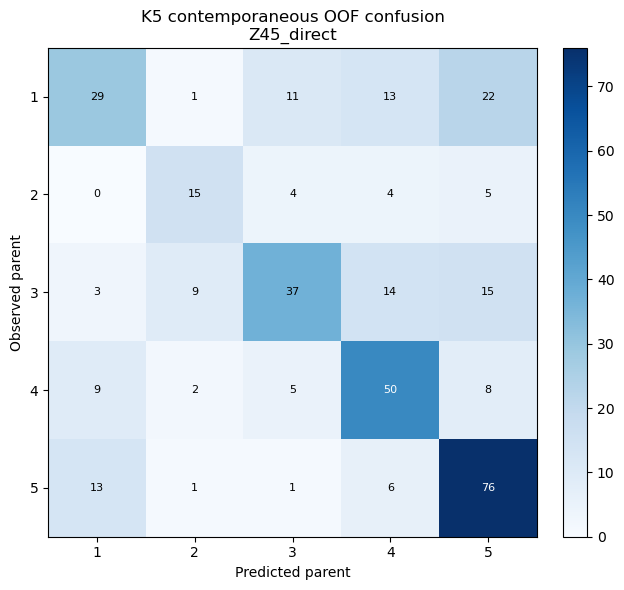

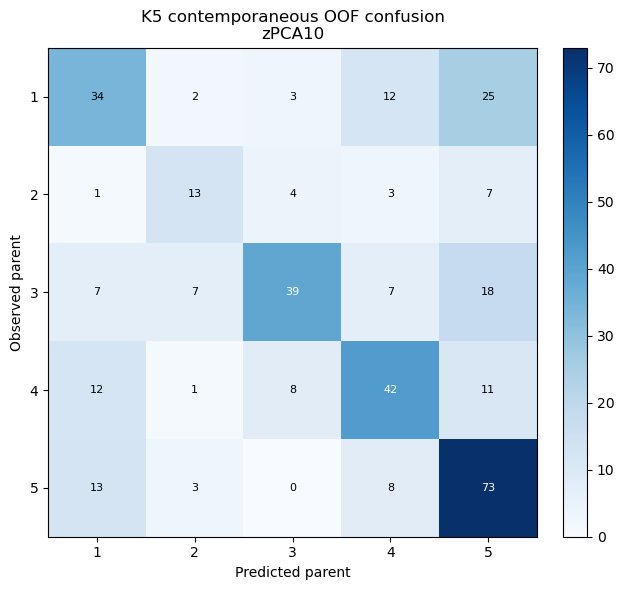

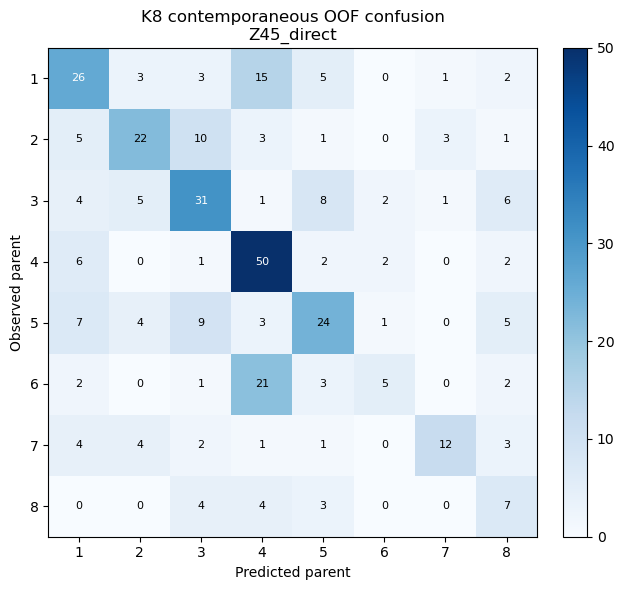

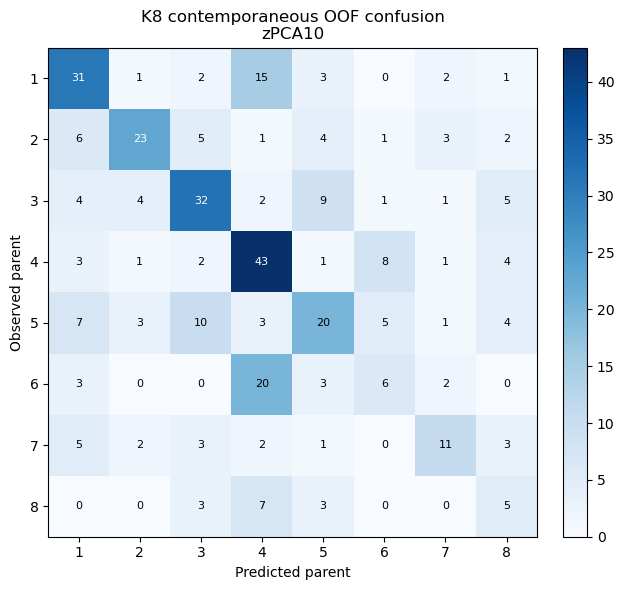

In [15]:
# =============================================================================
# 14. OOF CONFUSION MATRICES — Z45 VS zPCA10
#
# Confusion matrices include only held-out contemporaneous baseline observations.
# =============================================================================

for task_name, task in TASKS.items():

    y_baseline = analysis_df.loc[
        baseline_mask,
        task[
            "label_col"
        ],
    ].to_numpy(
        dtype=int
    )


    label_codes = task[
        "label_codes"
    ]


    for representation in [
        "Z45_direct",
        "zPCA10",
    ]:

        pred = z_oof_predictions[
            (
                task_name,
                representation,
            )
        ]


        cm = confusion_matrix(
            y_baseline,
            pred,
            labels=label_codes,
        )


        fig, ax = plt.subplots(
            figsize=(
                7,
                6,
            )
        )


        im = ax.imshow(
            cm,
            interpolation="nearest",
            cmap="Blues",
        )


        fig.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04,
        )


        ax.set_xticks(
            np.arange(
                len(
                    label_codes
                )
            )
        )

        ax.set_yticks(
            np.arange(
                len(
                    label_codes
                )
            )
        )

        ax.set_xticklabels(
            label_codes
        )

        ax.set_yticklabels(
            label_codes
        )

        ax.set_xlabel(
            "Predicted parent"
        )

        ax.set_ylabel(
            "Observed parent"
        )

        ax.set_title(
            f"{task_name} contemporaneous OOF confusion\n{representation}"
        )


        threshold = (
            cm.max()
            / 2.0
            if cm.size
            else 0
        )


        for i in range(
            cm.shape[
                0
            ]
        ):

            for j in range(
                cm.shape[
                    1
                ]
            ):

                ax.text(
                    j,
                    i,
                    str(
                        cm[
                            i,
                            j
                        ]
                    ),
                    ha="center",
                    va="center",
                    color=(
                        "white"
                        if cm[
                            i,
                            j
                        ] > threshold
                        else "black"
                    ),
                    fontsize=8,
                )


        plt.tight_layout()


        fig_path = (
            FIG_DIR
            / f"{task_name}_{representation}_contemporaneous_OOF_confusion.png"
        )


        fig.savefig(
            fig_path,
            dpi=250,
            bbox_inches="tight",
        )


        plt.show()
        plt.close(
            fig
        )

# Final sensitivity — raw versus annual-z geometry

This is secondary to the annual-z experiment.

The same contemporaneous test folds and the same guarded pseudo-2026 augmentation are used for all four representations:

- `Z45_direct`
- `zPCA10`
- `RAW45_direct`
- `rawPCA10`

Therefore differences are attributable to representation rather than different evaluation rows.

In [16]:
# =============================================================================
# 15. RAW VS Z — DIRECT AND PC10
# =============================================================================

raw_z_results = []


for task_name, task in TASKS.items():

    y_all = analysis_df[
        task[
            "label_col"
        ]
    ].to_numpy(
        dtype=int
    )


    specs = TASK_FOLD_SPECS[
        task_name
    ]


    # -------------------------------------------------------------------------
    # EXISTING ANNUAL-Z RESULTS
    # -------------------------------------------------------------------------

    for representation in [
        "Z45_direct",
        "zPCA10",
    ]:

        row = (
            z_results_df.loc[
                z_results_df[
                    "task"
                ].eq(
                    task_name
                )
                & z_results_df[
                    "representation"
                ].eq(
                    representation
                )
            ]
            .iloc[
                0
            ]
        )


        raw_z_results.append(
            {
                "task": task_name,
                "representation": representation,
                "geometry": "annual_z",
                **{
                    metric: row[
                        metric
                    ]
                    for metric in [
                        "accuracy",
                        "balanced_accuracy",
                        "macro_precision",
                        "macro_recall",
                        "macro_f1",
                        "weighted_f1",
                    ]
                },
            }
        )


    # -------------------------------------------------------------------------
    # RAW 45 DIRECT
    # -------------------------------------------------------------------------

    pred_raw_direct, metrics_raw_direct, _ = evaluate_direct_augmented_rf(
        X_all=X_raw,
        y_all=y_all,
        baseline_idx=baseline_idx,
        fold_specs=specs,
        label_codes=task[
            "label_codes"
        ],
    )


    raw_z_results.append(
        {
            "task": task_name,
            "representation": "RAW45_direct",
            "geometry": "raw",
            **metrics_raw_direct,
        }
    )


    # -------------------------------------------------------------------------
    # RAW PCA10
    # -------------------------------------------------------------------------

    pred_raw_pc10, metrics_raw_pc10, _ = evaluate_pca_augmented_rf(
        X_all=X_raw,
        y_all=y_all,
        baseline_idx=baseline_idx,
        fold_specs=specs,
        label_codes=task[
            "label_codes"
        ],
        n_components=FOCAL_PCA_K,
    )


    raw_z_results.append(
        {
            "task": task_name,
            "representation": "rawPCA10",
            "geometry": "raw",
            **metrics_raw_pc10,
        }
    )


raw_z_df = pd.DataFrame(
    raw_z_results
)


write_csv_safe(
    raw_z_df,
    TABLE_DIR
    / "DIAGNOSTIC_raw_vs_z_contemporaneous_OOF_RF_PC10.csv",
)


display(
    raw_z_df.sort_values(
        [
            "task",
            "representation",
        ]
    ).round(
        4
    )
)

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2\Tables\DIAGNOSTIC_raw_vs_z_contemporaneous_OOF_RF_PC10.csv


,task,representation,geometry,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
2,K5,RAW45_direct,raw,0.6034,0.5545,0.5681,0.5545,0.5560,0.5954
0,K5,Z45_direct,annual_z,0.5864,0.5702,0.5777,0.5702,0.5657,0.5763
3,K5,rawPCA10,raw,0.5779,0.5462,0.5560,0.5462,0.5487,0.5752
1,K5,zPCA10,annual_z,0.5694,0.5464,0.5716,0.5464,0.5511,0.5654
6,K8,RAW45_direct,raw,0.5241,0.4699,0.5125,0.4699,0.4741,0.5091
4,K8,Z45_direct,annual_z,0.5014,0.4654,0.5057,0.4654,0.4633,0.4896
7,K8,rawPCA10,raw,0.5156,0.4641,0.5006,0.4641,0.4692,0.5032
5,K8,zPCA10,annual_z,0.4844,0.4435,0.4623,0.4435,0.4451,0.4789


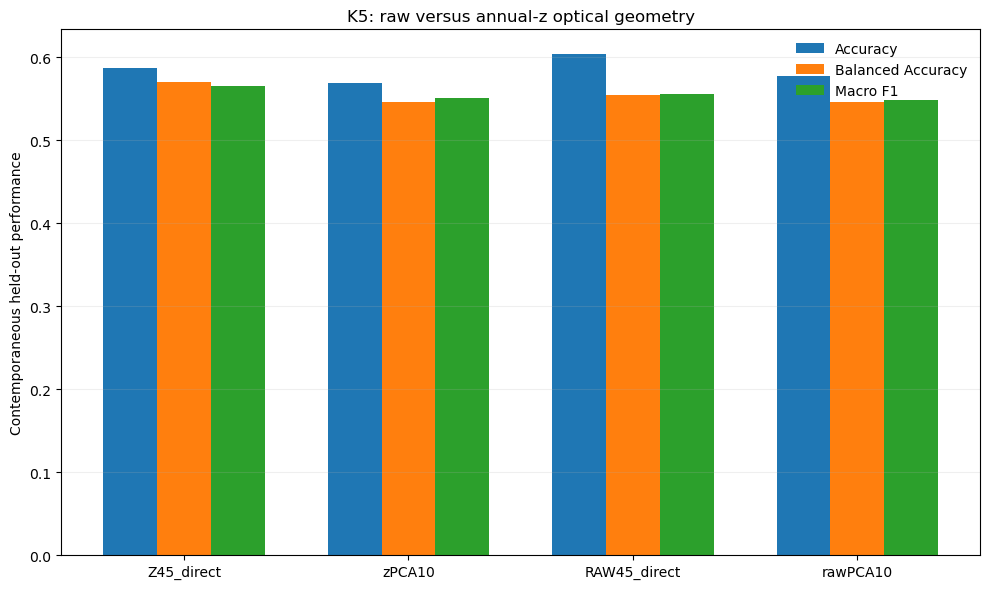

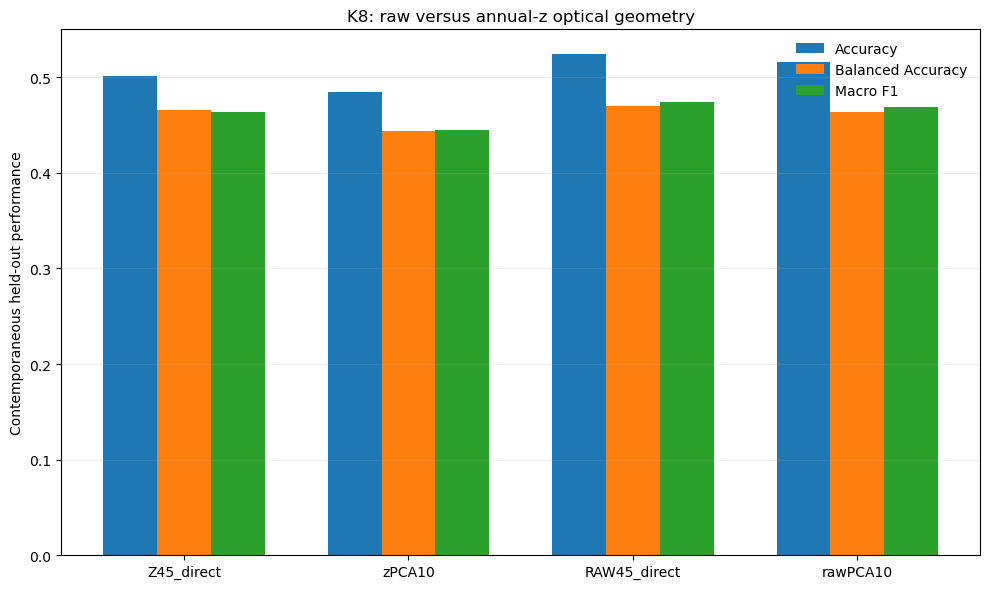

In [17]:
# =============================================================================
# 16. RAW VS Z SUMMARY FIGURES
# =============================================================================

metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
]


order = [
    "Z45_direct",
    "zPCA10",
    "RAW45_direct",
    "rawPCA10",
]


for task_name in [
    "K5",
    "K8",
]:

    part = raw_z_df.loc[
        raw_z_df[
            "task"
        ].eq(
            task_name
        )
    ].copy()


    part[
        "representation"
    ] = pd.Categorical(
        part[
            "representation"
        ],
        categories=order,
        ordered=True,
    )


    part = part.sort_values(
        "representation"
    )


    x = np.arange(
        len(
            part
        )
    )

    width = 0.24


    fig, ax = plt.subplots(
        figsize=(
            10,
            6,
        )
    )


    for i, metric in enumerate(
        metrics_to_plot
    ):

        ax.bar(
            x
            + (
                i - 1
            )
            * width,
            part[
                metric
            ],
            width=width,
            label=metric.replace(
                "_",
                " "
            ).title(),
        )


    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        [
            str(
                value
            )
            for value in part[
                "representation"
            ]
        ]
    )


    ax.set_ylabel(
        "Contemporaneous held-out performance"
    )

    ax.set_title(
        f"{task_name}: raw versus annual-z optical geometry"
    )

    ax.legend(
        frameon=False
    )

    ax.grid(
        axis="y",
        alpha=0.2
    )


    plt.tight_layout()


    fig_path = (
        FIG_DIR
        / f"{task_name}_raw_vs_z_PC10.png"
    )


    fig.savefig(
        fig_path,
        dpi=250,
        bbox_inches="tight",
    )


    plt.show()
    plt.close(
        fig
    )

## Interpretation guide

The primary contrasts are:

\[
Q(\mathrm{zPCA10})-Q(Z_{45}),
\]

which tests whether ten annual-z PCs retain the useful classifiable optical information, and

\[
Q(\mathrm{zPCA45})-Q(Z_{45}),
\]

which isolates the effect of rotating the full 45-dimensional feature space before RF classification.

The final sensitivity compares:

\[
Q(\mathrm{rawPCA10})
\quad\text{vs}\quad
Q(\mathrm{zPCA10}).
\]

Possible outcomes:

- **PC10 ≈ Z45**: most classifiable optical information is compressible into a lean space;
- **PC10 > Z45**: redundant/noisy dimensions may be degrading RF discrimination;
- **PC10 < Z45**: useful label information exists in lower-variance directions discarded by PCA;
- **PCA45 ≠ Z45**: RF is sensitive to the rotation itself;
- **rawPCA10 > zPCA10**: absolute optical geometry contains information suppressed by annual standardization;
- **zPCA10 > rawPCA10**: year-relative optical geometry is more classifiable.

### Validation scope

The reported OOF scores apply to held-out **contemporaneous baseline observations** inside the true NCA.

Pseudo-2026 rows are only diagnostic training augmentation and remain temporally mismatched to 2025 optics. They should not be interpreted as valid 2026 test observations.

The exclusion of `low69hagl` is also PCA-specific and should not be propagated to the vegetation master or future contemporaneous 2026 modeling.

In [18]:
# =============================================================================
# 17. OUTPUT MANIFEST
# =============================================================================

print(
    "=" * 100
)

print(
    "K5 / K8 PCA CLASSIFIABILITY DIAGNOSTIC — QC REVISION COMPLETE"
)

print(
    "=" * 100
)


print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)


for label, directory in [
    (
        "Tables",
        TABLE_DIR,
    ),
    (
        "Figures",
        FIG_DIR,
    ),
]:

    print(
        f"\n{label}:"
    )

    for path in sorted(
        directory.glob(
            "*"
        )
    ):

        print(
            " ",
            path.name
        )

K5 / K8 PCA CLASSIFIABILITY DIAGNOSTIC — QC REVISION COMPLETE

Output directory:
C:\NCA_DATA\Analysis\Diagnostics\K5_K8_PCA_Classifiability_Augmented2025_TrueNCA_QC_v2

Tables:
  DIAGNOSTIC_augmented_fold_composition.csv
  DIAGNOSTIC_common_trueNCA_augmented2025_after_PCA_QC.csv
  DIAGNOSTIC_PCA_specific_QC_exclusions.csv
  DIAGNOSTIC_raw_vs_z_contemporaneous_OOF_RF_PC10.csv
  DIAGNOSTIC_zPCA10_PCA45_delta_vs_Z45.csv
  DIAGNOSTIC_zPCA_contemporaneous_OOF_fold_performance.csv
  DIAGNOSTIC_zPCA_contemporaneous_OOF_performance.csv
  DIAGNOSTIC_zPCA_explained_variance.csv
  DIAGNOSTIC_zPCA_loadings_descriptive_only.csv

Figures:
  K5_raw_vs_z_PC10.png
  K5_Z45_direct_contemporaneous_OOF_confusion.png
  K5_zPCA10_contemporaneous_OOF_confusion.png
  K8_raw_vs_z_PC10.png
  K8_Z45_direct_contemporaneous_OOF_confusion.png
  K8_zPCA10_contemporaneous_OOF_confusion.png
  zPCA_accuracy_curve_K5_K8.png
  zPCA_balanced_accuracy_curve_K5_K8.png
  zPCA_cumulative_explained_variance.png
  zPCA_macro_f1